# Perceptron

The Perceptron is one of the earliest and most fundamental algorithms in machine learning. Introduced by Frank Rosenblatt in 1958, it's essentially a binary classifier that decides whether an input belongs to one class or another based on a linear decision boundary.

Think of it as the most basic version of a neural network: a singular neuron.

At its core, the perceptron takes an input vector x = [𝑥1,𝑥2,...,𝑥𝑛] , multiplies it by a weight vector w, adds a bias b, and applies an activation function which is typically the sign function:

output = sign(w ⋅ x + b)


If the result is positive, the perceptron outputs 1 (e.g., “positive class”).

If the result is negative, it outputs -1 (e.g., “negative class”).

The Perceptron uses an iterative update rule to adjust its weights whenever it misclassifies a data point. The update rule is:

𝑤 = 𝑤 + Δ𝑤 = 𝑤 + 𝜂(𝑦 - $\hat{y}$) 𝑥


Where:

η is the learning rate (how aggressively the weights change),

y is the true label,

$\hat{y}$ is the predicted label,

x is the input vector.

This update moves the decision boundary slightly in the direction that corrects the mistake, a process that repeats over many epochs until the algorithm either converges or hits a stopping condition.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

Though this simplification may slightly reduce classification accuracy, it’s ideal for visual demonstration of the Perceptron’s behavior — especially how it draws a linear boundary in a real-world, medically-relevant dataset.

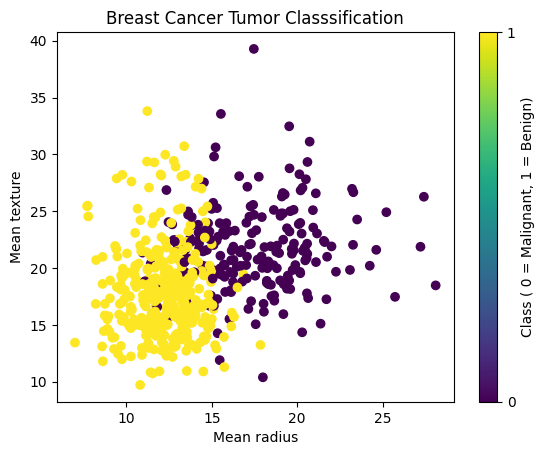

In [34]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [35]:
#Implementation of the Perceptron class
class Perceptron:
    def __init__(self, learning_rate=0.01, n_epochs=1000):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.weights = None
        self.bias = None
    
    def activation(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for epoch in range(self.n_epochs):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = self.activation(linear_output)
                error = y[idx] - y_pred
                # Update rule
                self.weights += self.lr * error * x_i
                self.bias += self.lr * error

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)

In [36]:
#Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
#Running the analysis with the Perceptron Class
my_perc = Perceptron(learning_rate=0.01, n_epochs=1000)
my_perc.fit(X_train_scaled, y_train)
y_pred_custom = my_perc.predict(X_test_scaled)
acc_custom = accuracy_score(y_test, y_pred_custom)
print(f"Custom Perceptron Accuracy: {acc_custom:.4f}")

Custom Perceptron Accuracy: 0.9298


In [38]:
#Running the analysis with the scikit Perceptron Class
sk_perc = SklearnPerceptron(max_iter=1000, eta0=0.01, random_state=42)
sk_perc.fit(X_train_scaled, y_train)
y_pred_sklearn = sk_perc.predict(X_test_scaled)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Sklearn Perceptron Accuracy: {acc_sklearn:.4f}")

Sklearn Perceptron Accuracy: 0.9912


In [39]:
#Comparing Results
print("\nComparison:")
print(f"Custom Perceptron correct: {(y_pred_custom == y_test).sum()} / {len(y_test)}")
print(f"Sklearn Perceptron correct: {(y_pred_sklearn == y_test).sum()} / {len(y_test)}")


Comparison:
Custom Perceptron correct: 106 / 114
Sklearn Perceptron correct: 113 / 114


Our model has efficacy comparable to that of scikit-learn! Further improving the code would hopefully bring our accuracy up and match the standard method.

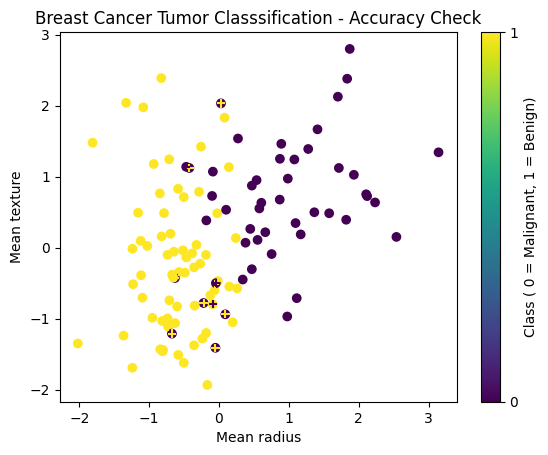

In [40]:
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c = y_pred_custom)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c = y_test, marker = '+')

plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification - Accuracy Check')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')
     

Most of the wrong cases are false positives, which in this context is great and can save lives! We also see that the wrongly classified instances are not necessarily near the edge between clusters.

While the Perceptron achieves good accuracy and avoids the most dangerous errors, it lacks the flexibility to model complex, non-linear patterns. For more robust performance, especially on the full 30-feature dataset, we’d likely need a more expressive model (e.g., logistic regression with polynomial terms, SVMs, or neural networks).